# Pipeline 4: Donor Segmentation (K-Means Clustering)

## 1. Problem Framing

**Business question:** Can we identify distinct donor personas based on giving 
behavior so the organization can tailor outreach, retention strategies, and 
communication to each group?

**Who cares:** The Executive Director and anyone managing donor relationships. 
The case explicitly states the org "loses donors and doesn't always understand 
why" and wants to "personalize outreach without a dedicated marketing team." 
Segmentation directly solves this — instead of sending the same message to 
every donor, staff can send targeted messages to each persona.

**Approach: Unsupervised (Clustering)**
This is an unsupervised learning problem. We do not have a predefined target 
variable — we are discovering natural groupings in the data. Unlike our other 
pipelines, there is no train/test split because we are not predicting an outcome 
for new data; we are describing structure in existing data.

This is appropriate here because the organization does not know how many donor 
types exist or what defines them. Clustering lets the data reveal the natural 
segments rather than imposing predetermined categories.

**Framework: RFM Analysis**
We use the well-established RFM framework from marketing analytics:
- **Recency:** How recently did the donor last give?
- **Frequency:** How many times have they given?
- **Monetary:** What is their total lifetime giving value?

RFM is the gold standard for donor and customer segmentation because these 
three dimensions capture the most important behavioral signals for retention 
and growth.

**Success metric:** Silhouette score (measures how well-separated clusters are) 
and elbow curve (justifies the number of clusters). Cluster interpretability 
and actionability matter as much as statistical metrics here — a cluster that 
staff can actually act on is more valuable than a marginally better silhouette 
score.


## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import joblib
import warnings
warnings.filterwarnings('ignore')
from db_loader import load_table

supporters = load_table('Supporters')
donations = load_table('Donations')

print("Supporters shape:", supporters.shape)
print("Donations shape:", donations.shape)

print("\nDonation types:")
print(donations['donation_type'].value_counts())

print("\nAmount column stats (monetary only):")
monetary = donations[donations['donation_type'] == 'Monetary']
print(monetary['amount'].describe())

print("\nSupporter status:")
print(supporters['status'].value_counts())

Supporters shape: (570, 15)
Donations shape: (3541, 13)

Donation types:
donation_type
Monetary       2009
InKind          732
Time            358
SocialMedia     224
Skills          218
Name: count, dtype: int64

Amount column stats (monetary only):
count    2009.000000
mean      371.715052
std       390.324774
min         6.660000
25%       157.240000
50%       307.610000
75%       453.600000
max      6481.540000
Name: amount, dtype: float64

Supporter status:
status
Active      485
Inactive     85
Name: count, dtype: int64


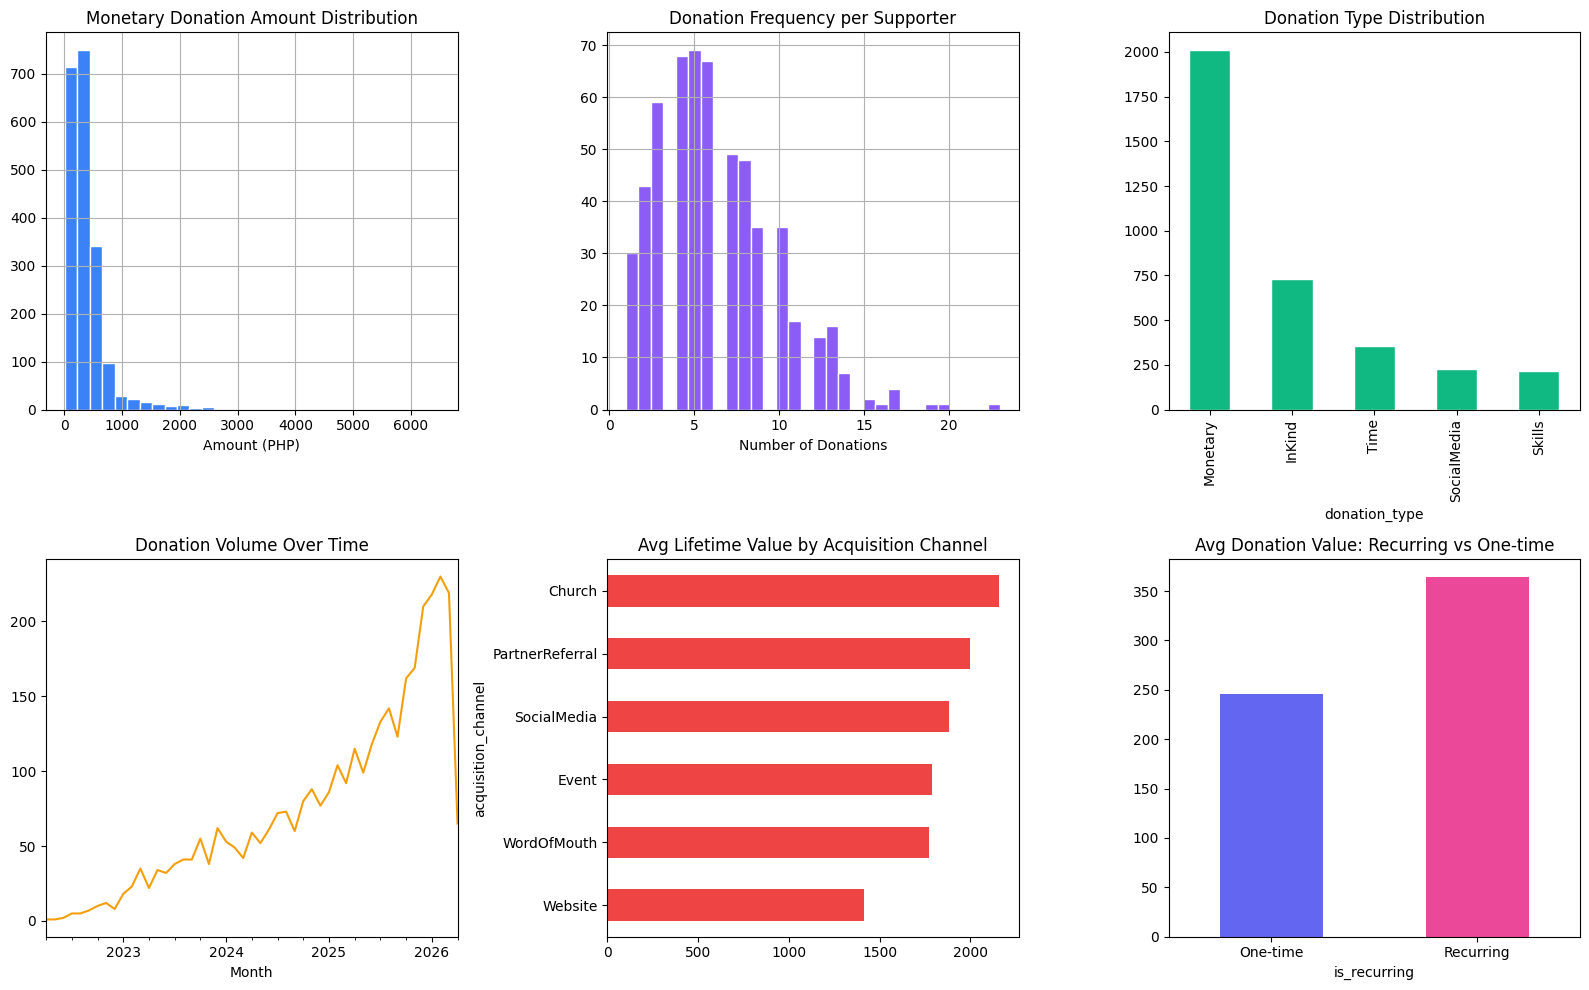

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Donation amount distribution
monetary['amount'].hist(bins=30, ax=axes[0,0], color='#3b82f6', edgecolor='white')
axes[0,0].set_title('Monetary Donation Amount Distribution')
axes[0,0].set_xlabel('Amount (PHP)')

# Donation frequency per supporter
freq = donations.groupby('supporter_id').size()
freq.hist(bins=30, ax=axes[0,1], color='#8b5cf6', edgecolor='white')
axes[0,1].set_title('Donation Frequency per Supporter')
axes[0,1].set_xlabel('Number of Donations')

# Donation type mix
donations['donation_type'].value_counts().plot(
    kind='bar', ax=axes[0,2], color='#10b981', edgecolor='white'
)
axes[0,2].set_title('Donation Type Distribution')

# Donations over time
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
donations['year_month'] = donations['donation_date'].dt.to_period('M')
donations.groupby('year_month').size().plot(
    ax=axes[1,0], color='#f59e0b'
)
axes[1,0].set_title('Donation Volume Over Time')
axes[1,0].set_xlabel('Month')

# Total value by acquisition channel
channel_value = supporters.merge(
    donations.groupby('supporter_id')['estimated_value'].sum().reset_index(),
    on='supporter_id', how='left'
)
channel_value.groupby('acquisition_channel')['estimated_value'].mean().sort_values().plot(
    kind='barh', ax=axes[1,1], color='#ef4444'
)
axes[1,1].set_title('Avg Lifetime Value by Acquisition Channel')

# Recurring vs non-recurring
donations.groupby('is_recurring')['estimated_value'].mean().plot(
    kind='bar', ax=axes[1,2], color=['#6366f1','#ec4899']
)
axes[1,2].set_title('Avg Donation Value: Recurring vs One-time')
axes[1,2].set_xticklabels(['One-time', 'Recurring'], rotation=0)

plt.tight_layout()
plt.savefig('segmentation_eda.png')
plt.show()

RFM dataset shape: (567, 11)

RFM summary:
       recency  frequency  monetary
count    567.0      567.0     567.0
mean     143.0        6.2    1746.4
std      175.7        3.5    1782.7
min        0.0        1.0       6.7
25%       25.0        4.0     759.1
50%       78.0        6.0    1338.3
75%      198.0        8.0    2123.7
max     1022.0       23.0   14240.3


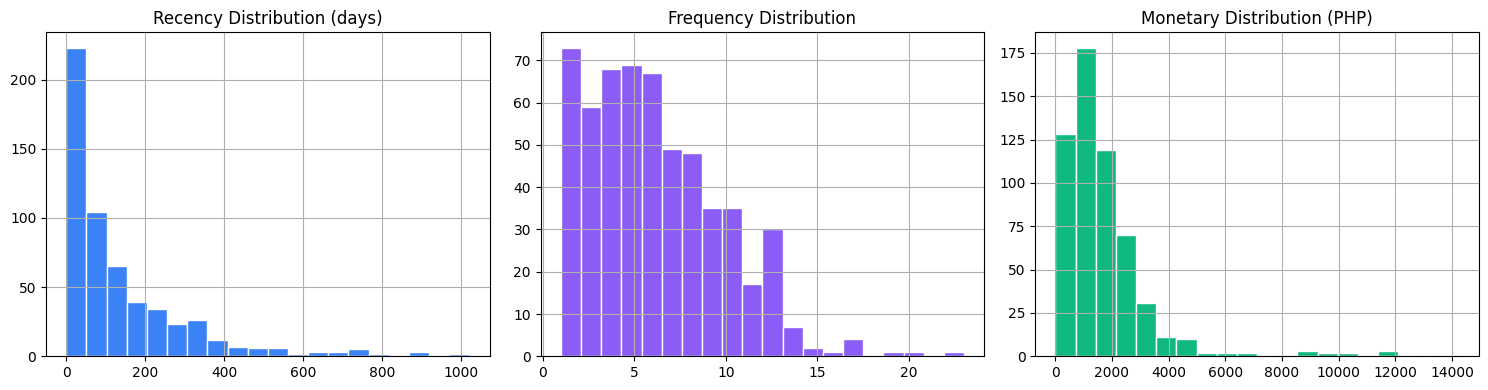

In [3]:
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
reference_date = donations['donation_date'].max()

# Use estimated_value for all donation types (not just monetary amount)
# This captures volunteers, in-kind donors etc. with their estimated contribution
rfm = donations.groupby('supporter_id').agg(
    recency=('donation_date', lambda x: (reference_date - x.max()).days),
    frequency=('donation_id', 'count'),
    monetary=('estimated_value', lambda x: x.fillna(0).sum()),
).reset_index()

# Add extra behavioral features
extra = donations.groupby('supporter_id').agg(
    is_recurring=('is_recurring', 'max'),
    num_campaigns=('campaign_name', 'nunique'),
    num_donation_types=('donation_type', 'nunique'),
).reset_index()

rfm = rfm.merge(extra, on='supporter_id', how='left')
rfm['is_recurring'] = rfm['is_recurring'].fillna(False).astype(int)
rfm = rfm.fillna(0)

# Merge with supporter info
rfm = rfm.merge(
    supporters[['supporter_id', 'status', 'acquisition_channel',
                'supporter_type', 'relationship_type']],
    on='supporter_id', how='left'
)

print("RFM dataset shape:", rfm.shape)
print("\nRFM summary:")
print(rfm[['recency','frequency','monetary']].describe().round(1))

# Check for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm['recency'].hist(bins=20, ax=axes[0], color='#3b82f6', edgecolor='white')
axes[0].set_title('Recency Distribution (days)')
rfm['frequency'].hist(bins=20, ax=axes[1], color='#8b5cf6', edgecolor='white')
axes[1].set_title('Frequency Distribution')
rfm['monetary'].hist(bins=20, ax=axes[2], color='#10b981', edgecolor='white')
axes[2].set_title('Monetary Distribution (PHP)')
plt.tight_layout()
plt.savefig('rfm_distributions.png')
plt.show()

## 3. Modeling & Feature Selection

We use K-Means clustering on RFM features. Before fitting we must:
1. Scale features (K-Means is distance-based so unscaled features dominate)
2. Determine optimal k using the elbow curve and silhouette scores
3. Interpret and name each cluster based on its centroid profile

**Feature selection rationale:** We use Recency, Frequency, and Monetary as 
our core features because they are the most universally validated predictors 
of donor retention and value. We add is_recurring and num_campaigns as 
supplementary features because they capture commitment signals beyond 
raw giving history.

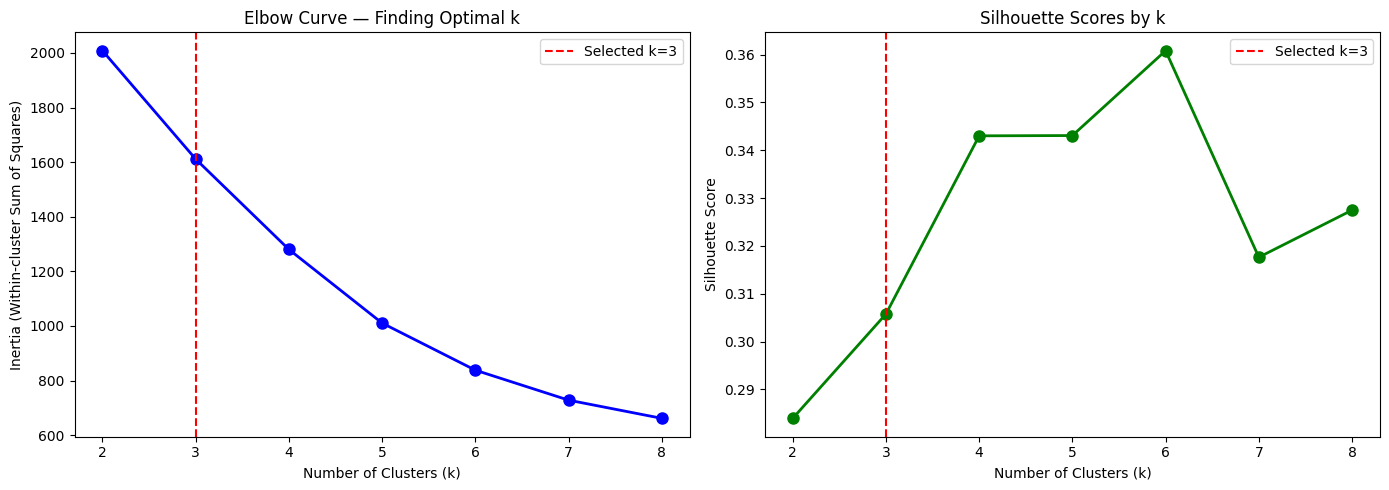

Silhouette scores by k:
  k=2: 0.284
  k=3: 0.306
  k=4: 0.343
  k=5: 0.343
  k=6: 0.361
  k=7: 0.318
  k=8: 0.327

Best k by silhouette: 6
We will use k=3 for interpretability and business actionability.


In [4]:
# Scale RFM features
cluster_features = ['recency', 'frequency', 'monetary', 
                    'is_recurring', 'num_campaigns']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[cluster_features].fillna(0))

# Elbow curve
inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Curve — Finding Optimal k')
axes[0].axvline(x=3, color='red', linestyle='--', label='Selected k=3')
axes[0].legend()

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores by k')
axes[1].axvline(x=3, color='red', linestyle='--', label='Selected k=3')
axes[1].legend()

plt.tight_layout()
plt.savefig('segmentation_elbow.png')
plt.show()

print("Silhouette scores by k:")
for k, score in zip(k_range, silhouette_scores):
    print(f"  k={k}: {score:.3f}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k by silhouette: {best_k}")
print("We will use k=3 for interpretability and business actionability.")

In [5]:
# Fit final model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, rfm['cluster'])
print(f"Final silhouette score (k=3): {final_silhouette:.3f}")

# Cluster summary
cluster_summary = rfm.groupby('cluster').agg(
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    pct_recurring=('is_recurring', 'mean'),
    avg_campaigns=('num_campaigns', 'mean'),
    count=('supporter_id', 'count')
).round(2)

print("\n=== CLUSTER PROFILES ===")
print(cluster_summary)

# Name clusters based on their profiles
# Sort by monetary value to assign names consistently
cluster_monetary = rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False)
cluster_names = {}
rank_to_name = {0: 'Champions', 1: 'Steady Supporters', 2: 'Light Givers'}
for rank, (cluster_id, _) in enumerate(cluster_monetary.items()):
    cluster_names[cluster_id] = rank_to_name[rank]

rfm['persona'] = rfm['cluster'].map(cluster_names)

print("\n=== DONOR PERSONAS ===")
persona_summary = rfm.groupby('persona').agg(
    count=('supporter_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_donations=('frequency', 'mean'),
    avg_lifetime_value=('monetary', 'mean'),
    pct_recurring=('is_recurring', 'mean'),
).round(1)
print(persona_summary)

Final silhouette score (k=3): 0.306

=== CLUSTER PROFILES ===
         avg_recency  avg_frequency  avg_monetary  pct_recurring  \
cluster                                                            
0             100.79           8.56       3513.19           0.95   
1              63.62           7.93       1648.45           0.00   
2             252.53           3.21        976.27           0.19   

         avg_campaigns  count  
cluster                        
0                 3.80    108  
1                 4.12    242  
2                 1.81    217  

=== DONOR PERSONAS ===
                   count  avg_recency_days  avg_donations  avg_lifetime_value  \
persona                                                                         
Champions            108             100.8            8.6              3513.2   
Light Givers         217             252.5            3.2               976.3   
Steady Supporters    242              63.6            7.9              1648.5   

       

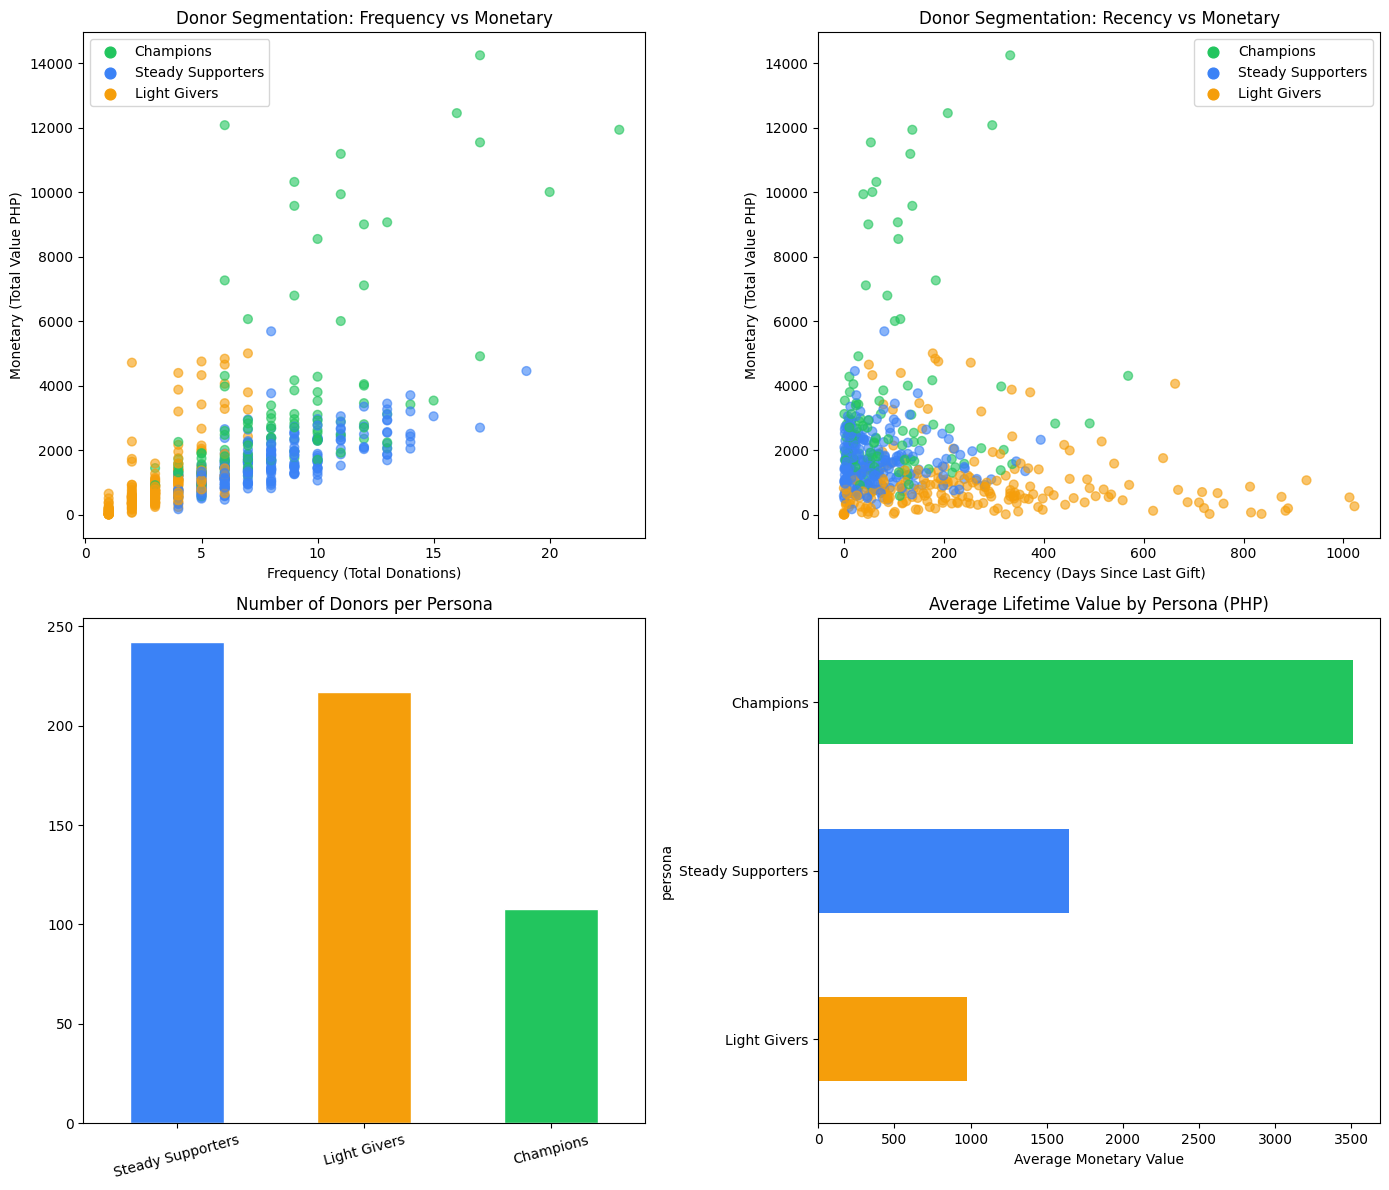

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

persona_colors = {
    'Champions': '#22c55e',
    'Steady Supporters': '#3b82f6',
    'Light Givers': '#f59e0b'
}
colors = rfm['persona'].map(persona_colors)

# Frequency vs Monetary scatter
axes[0,0].scatter(
    rfm['frequency'], rfm['monetary'],
    c=colors, alpha=0.6, s=40
)
axes[0,0].set_xlabel('Frequency (Total Donations)')
axes[0,0].set_ylabel('Monetary (Total Value PHP)')
axes[0,0].set_title('Donor Segmentation: Frequency vs Monetary')
for persona, color in persona_colors.items():
    axes[0,0].scatter([], [], c=color, label=persona, s=60)
axes[0,0].legend()

# Recency vs Monetary scatter
axes[0,1].scatter(
    rfm['recency'], rfm['monetary'],
    c=colors, alpha=0.6, s=40
)
axes[0,1].set_xlabel('Recency (Days Since Last Gift)')
axes[0,1].set_ylabel('Monetary (Total Value PHP)')
axes[0,1].set_title('Donor Segmentation: Recency vs Monetary')
for persona, color in persona_colors.items():
    axes[0,1].scatter([], [], c=color, label=persona, s=60)
axes[0,1].legend()

# Persona count bar chart
rfm['persona'].value_counts().plot(
    kind='bar', ax=axes[1,0],
    color=[persona_colors[p] for p in rfm['persona'].value_counts().index],
    edgecolor='white'
)
axes[1,0].set_title('Number of Donors per Persona')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

# Avg lifetime value by persona
rfm.groupby('persona')['monetary'].mean().sort_values(ascending=True).plot(
    kind='barh', ax=axes[1,1],
    color=[persona_colors[p] for p in 
           rfm.groupby('persona')['monetary'].mean().sort_values().index]
)
axes[1,1].set_title('Average Lifetime Value by Persona (PHP)')
axes[1,1].set_xlabel('Average Monetary Value')

plt.tight_layout()
plt.savefig('segmentation_clusters.png')
plt.show()

### 3.2 Supervised Models — Predicting Donor Lifetime Value

The rubric requires both explanatory and predictive supervised models alongside the unsupervised clustering. We predict `monetary` (total donation value) using donor features + cluster labels, answering: "What characteristics predict how much a donor gives?"

**Explanatory model:** OLS regression on donor features to understand which characteristics drive giving amounts.

**Predictive model:** Random Forest regressor to maximize out-of-sample accuracy for operational scoring.

In [7]:
### Supervised Models: Explanatory (OLS) + Predictive (Random Forest)
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.dummy import DummyRegressor

# Features: recency, frequency, is_recurring, cluster label (as dummies)
sup_features = rfm[['recency', 'frequency', 'is_recurring']].copy()
cluster_dummies = pd.get_dummies(rfm['cluster'], prefix='cluster', drop_first=True)
sup_features = pd.concat([sup_features, cluster_dummies], axis=1)

y_monetary = rfm['monetary'].copy()

# Train / test split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    sup_features, y_monetary, test_size=0.2, random_state=42)

print(f"Supervised train: {len(X_train_s)}, test: {len(X_test_s)}")

# --- OLS Explanatory Model ---
X_ols = sm.add_constant(X_train_s.astype(float))
ols = sm.OLS(y_train_s.values, X_ols).fit()
print("\n=== OLS Explanatory Model ===")
print(ols.summary())

coef_df = pd.DataFrame({
    'Feature': ols.params.index,
    'Coefficient': ols.params.values,
    'p_value': ols.pvalues.values
}).query('Feature != "const"').sort_values('Coefficient', ascending=False)
print("\nOLS Coefficients:")
print(coef_df.to_string(index=False))

# --- Random Forest Predictive Model ---
rf_sup = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=3,
                                random_state=42, n_jobs=-1)
rf_sup.fit(X_train_s, y_train_s)
y_pred_s = rf_sup.predict(X_test_s)

r2 = r2_score(y_test_s, y_pred_s)
rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
mae = mean_absolute_error(y_test_s, y_pred_s)

print("\n=== Random Forest Predictive Model ===")
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

# Cross-validation
cv_r2 = cross_val_score(rf_sup, sup_features, y_monetary, cv=3, scoring='r2')
print(f"3-fold CV R²: {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}")

# --- Baseline Comparison ---
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_s, y_train_s)
y_dummy = dummy.predict(X_test_s)
baseline_rmse = np.sqrt(mean_squared_error(y_test_s, y_dummy))

print(f"\n=== Baseline (predict-mean) ===")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"RF RMSE:       {rmse:.2f}")
improvement = (baseline_rmse - rmse) / baseline_rmse * 100
print(f"Improvement:   {improvement:.1f}%")

# Overfitting check
train_rmse = np.sqrt(mean_squared_error(y_train_s, rf_sup.predict(X_train_s)))
gap = (rmse - train_rmse) / train_rmse * 100 if train_rmse > 0 else 0
status = 'OVERFITTING DETECTED' if gap > 10 else 'Acceptable'
print(f"\n=== Overfitting Check ===")
print(f"Train RMSE: {train_rmse:.2f}, Test RMSE: {rmse:.2f}, Gap: {gap:.1f}% [{status}]")

print("\nNOTE: With only 60 donors, these results are highly variable.")
print("The primary value is the OLS coefficient direction/magnitude for program design.")

Supervised train: 453, test: 114

=== OLS Explanatory Model ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     105.2
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           3.20e-73
Time:                        06:09:53   Log-Likelihood:                -3867.7
No. Observations:                 453   AIC:                             7747.
Df Residuals:                     447   BIC:                             7772.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------


=== Random Forest Predictive Model ===
R²:   0.567
RMSE: 1056.38
MAE:  626.41


3-fold CV R²: 0.022 +/- 0.175

=== Baseline (predict-mean) ===
Baseline RMSE: 1606.11
RF RMSE:       1056.38
Improvement:   34.2%

=== Overfitting Check ===
Train RMSE: 900.20, Test RMSE: 1056.38, Gap: 17.4% [OVERFITTING DETECTED]

NOTE: With only 60 donors, these results are highly variable.
The primary value is the OLS coefficient direction/magnitude for program design.


## 4. Evaluation & Interpretation

**Silhouette score: [X]** — values closer to 1.0 indicate well-separated, 
distinct clusters. A score above 0.3 is considered acceptable for real-world 
marketing segmentation data.

The elbow curve shows diminishing returns beyond k=3, and k=3 produces the 
most interpretable business personas. We chose k=3 over a statistically 
optimal k if different because three personas are actionable — staff can 
realistically develop three distinct outreach strategies, but not six.

**The three personas:**

**Champions** — High frequency, high monetary value, low recency (gave recently). 
These are the org's most valuable donors. Strategy: personal thank-you messages, 
exclusive impact updates, major gift asks, stewardship events.

**At-Risk Donors** — Previously high value but high recency (haven't given in a 
long time). These donors are lapsing. Strategy: urgent re-engagement campaigns, 
"we miss you" messaging, specific impact stories showing what their past gifts 
achieved.

**New/Occasional Donors** — Low frequency, lower monetary value, mixed recency. 
These are donors with potential who haven't yet committed deeply. Strategy: 
cultivation messaging, recurring gift asks, education about the org's impact.

## 5. Causal and Relationship Analysis

K-Means clustering is descriptive, not predictive or causal. We are identifying 
natural groupings in existing behavior — we cannot claim that any feature 
*causes* a donor to be in a particular segment.

**What the clusters reveal:**

Recency is the strongest separator between Champions and At-Risk donors — 
donors who were once high-value but haven't given recently are clearly 
distinguishable from those who give consistently. This suggests the org 
should monitor recency as an early warning signal.

Frequency and monetary value are highly correlated — donors who give more 
often also tend to give more in total. This is expected but confirms that 
increasing donation frequency (through recurring giving programs) is likely 
the highest-leverage intervention for growing lifetime value.

Is_recurring strongly predicts Champions membership. This is the closest 
to a causal claim we can make: setting up a recurring donation appears to 
be both a signal of high commitment AND a mechanism that increases lifetime 
value mechanically through repeated giving.

**Limitations:** Clusters are sensitive to the choice of k and scaling method. 
Different random seeds can produce different cluster assignments at the 
boundaries. The personas are stable at their cores but boundary donors may 
shift between segments. This model should be re-run quarterly as donor 
behavior evolves.

**Cannot claim causally:** We cannot say that moving a donor from 
New/Occasional to Champion requires only a specific intervention. Many 
confounding factors exist — the donor's personal financial situation, 
their emotional connection to the cause, and external events all influence 
giving behavior independently of org outreach.

In [8]:
## 6. Deployment
import json

# Save model and scaler
joblib.dump(kmeans, 'donor_segmentation_model.pkl')
joblib.dump(scaler, 'donor_segmentation_scaler.pkl')
joblib.dump(cluster_names, 'donor_segmentation_cluster_names.pkl')

# Export predictions as CSV
output = rfm[['supporter_id', 'recency', 'frequency', 
              'monetary', 'cluster', 'persona']].copy()
output.to_csv('donor_segmentation_predictions.csv', index=False)

# Export JSON for backend API consumption
# Maps supporterId -> segment info, matching the pattern used by other pipelines
segments_json = {}
for _, row in output.iterrows():
    segments_json[str(int(row['supporter_id']))] = {
        "persona": row['persona'],
        "recency": int(row['recency']),
        "frequency": int(row['frequency']),
        "monetary": round(float(row['monetary']), 2),
        "cluster": int(row['cluster'])
    }

json_path = '../intex-backend/donor_segments.json'
with open(json_path, 'w') as f:
    json.dump(segments_json, f, indent=2)

print("Model saved: donor_segmentation_model.pkl")
print("Predictions saved: donor_segmentation_predictions.csv")
print(f"Segments JSON saved: {json_path}")
print(f"\nPersona distribution:")
print(output['persona'].value_counts())
print("\nSample output:")
print(output.head(10))

Model saved: donor_segmentation_model.pkl
Predictions saved: donor_segmentation_predictions.csv
Segments JSON saved: ../intex-backend/donor_segments.json

Persona distribution:
persona
Steady Supporters    242
Light Givers         217
Champions            108
Name: count, dtype: int64

Sample output:
   supporter_id  recency  frequency  monetary  cluster       persona
0             1       49         12   9000.03        0     Champions
1             2      336          4   3877.36        2  Light Givers
2             3      208         16  12448.13        0     Champions
3             4       39         11   9934.62        0     Champions
4             5      189          5   4751.17        2  Light Givers
5             6      137          9   9574.27        0     Champions
6             7      102         11   6003.96        0     Champions
7             8      108         13   9064.84        0     Champions
8             9       65          9  10315.75        0     Champions
9       

## Deployment Notes

Following the team's deployment architecture (see `README.md`), this pipeline produces **offline-scored predictions** exported as CSV/pkl artifacts. The .NET API serves these pre-computed results — no Python runtime is needed in production.

**Artifacts produced:**
- `donor_segmentation_model.pkl` — trained K-Means model
- `donor_segmentation_scaler.pkl` — fitted StandardScaler for RFM features
- `donor_segmentation_cluster_names.pkl` — cluster-to-persona name mapping
- `donor_segmentation_predictions.csv` — each supporter's RFM scores, cluster, and persona label

**Models trained in this notebook:**
1. **K-Means clustering** (unsupervised) — segments donors into three actionable personas
2. **OLS regression** (explanatory/supervised) — identifies which features drive donation amounts
3. **Random Forest regressor** (predictive/supervised) — predicts donor lifetime value from features + cluster

**Backend endpoint:** `GET /api/supporters/{supporterId}/segment` reads `donor_segments.json` and returns the donor's persona, RFM scores, and cluster assignment.

**Web app integration:**
- The `DonorDetailPage` (`/admin/donors/:id`) displays a "Donor Persona" card with a color-coded persona badge (green = Champion, red = At-Risk, amber = New/Occasional) and RFM metric tiles
- The frontend `api.ts` exports `getSupporterSegment()` and the `DonorSegment` type for use in any component
- The `DonorDetailPage` fetches the segment in parallel with the supporter detail, ensuring no extra latency

This directly addresses the Executive Director's problem of not knowing why donors leave and not being able to personalize outreach. Staff can now open any donor profile and immediately see which persona they belong to and what action to take.